# MS4 Algorithm 02BA Analysis

Percussion/plucked string algorithm used by 12 MS4 programs.
Includes marimba, steel guitar, banjo, ukulele, zither, and similar instruments.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sam8905_interpreter import (
    SAM8905Interpreter,
    plot_waveform,
    export_wav,
    print_state,
)
from sam8905_aram_decoder import decode_algorithm, analyze_dram_usage
from ms4_programs import ALGORITHMS, PROGRAMS_02BA

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Algorithm Decode

Disassemble the A-RAM instructions and analyze D-RAM usage.

In [2]:
# Load algorithm
aram_02ba = ALGORITHMS['02BA']

# Decode and display
print(decode_algorithm(aram_02ba))

# D-RAM usage analysis
print("\nD-RAM Usage:")
usage = analyze_dram_usage(aram_02ba)
for addr, counts in sorted(usage.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")


PC00: 79F5  RM 15, <WXY, WWF, WSP> ***
PC01: 30EF  RM 6, <WPHI>
PC02: 60F7  RM 12, <WXY>
PC03: 587F  RM 11, <WA>
PC04: 7CBF  RP, <WB>
PC05: 5ACF  RADD 11, <WM, WPHI>
PC06: 38F7  RM 7, <WXY>
PC07: 11EF  RM 2, <WPHI, WSP> ***
PC08: 20FD  RM 4, <WWF>
PC09: 086E  RM 1, <WA, WPHI, WACC>
PC10: 68BF  RM 13, <WB>
PC11: 4ADF  RADD 9, <WM>
PC12: 113F  RM 2, <WA, WB, WSP> ***
PC13: 52DF  RADD 10, <WM>
PC14: 18BF  RM 3, <WB>
PC15: 53DF  RADD 10, <WM, WSP> ***
PC16: 28F7  RM 5, <WXY>
PC17: 51EF  RM 10, <WPHI, WSP> ***
PC18: 20FD  RM 4, <WWF>
PC19: 48EF  RM 9, <WPHI>
PC20: 4CDF  RP 9, <WM>
PC21: 703F  RM 14, <WA, WB>
PC22: 7A3F  RADD, <WA, WB>
PC23: 7A3F  RADD, <WA, WB>
PC24: 7A7F  RADD, <WA>
PC25: 78BF  RM 15, <WB>
PC26: 28F7  RM 5, <WXY>
PC27: 7ADF  RADD 15, <WM>
PC28: 54DF  RP 10, <WM>
PC29: 7FFF  RSP, <WSP> ***
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 1]: read=1, write=0
  D[ 2]: read=2, write=0
  D[ 3]: read=1, write=0
  D[ 4]: read=2, write=0
  D[ 5]: read=2, w

## Available Programs

List all programs using this algorithm.

In [3]:
print(f"Programs using algorithm 02BA ({len(PROGRAMS_02BA)} total):\n")
for i, prog in enumerate(PROGRAMS_02BA):
    print(f"{i:2d}. [{prog['idx']:2d}] {prog['name']:<12} slots={prog['slot_count']} "
          f"dram0=0x{prog['dram_entry0']['word']:04X}")

Programs using algorithm 02BA (12 total):

 0. [13] dmarimb      slots=1 dram0=0x4401
 1. [14] dsteelg      slots=1 dram0=0x5402
 2. [18] dstrath      slots=1 dram0=0x8402
 3. [19] djguit       slots=1 dram0=0x1402
 4. [26] dstee        slots=1 dram0=0x4402
 5. [28] dbanjo       slots=1 dram0=0xC401
 6. [29] dstratl      slots=1 dram0=0xE402
 7. [31] dstopg2      slots=1 dram0=0xA402
 8. [47] dzith2       slots=1 dram0=0x6402
 9. [50] dukule       slots=1 dram0=0x0402
10. [53] dkalimb      slots=1 dram0=0x2401
11. [56] dkvoi2       slots=1 dram0=0xE402


## Program Selection

In [4]:
# Select program by index in PROGRAMS_02BA list (0-11)
PROGRAM_INDEX = 0  # Change this to select different program

prog = PROGRAMS_02BA[PROGRAM_INDEX]
print(f"Selected: {prog['name']} (MS4 program #{prog['idx']})")
print(f"  Flags: 0x{prog['flags']:02X}, Slots: {prog['slot_count']}")
print(f"  D-RAM entry0: word=0x{prog['dram_entry0']['word']:04X}")

# Voice slot data
if prog['voice_slots']:
    print(f"\n  Voice slots ({len(prog['voice_slots'])}):\n")
    for i, slot in enumerate(prog['voice_slots']):
        data_hex = ' '.join(f'{b:02X}' for b in slot['data'])
        print(f"    Slot {i}: ptr=0x{slot['ptr']:04X} data=[{data_hex}]")
        d = slot['data']
        env_ptr = d[0] | (d[1] << 8)
        print(f"            env_tbl=0x{env_ptr:04X}, ctrl=0x{d[2]:02X}")

Selected: dmarimb (MS4 program #13)
  Flags: 0x11, Slots: 1
  D-RAM entry0: word=0x4401

  Voice slots (2):

    Slot 0: ptr=0x0CF8 data=[A1 07 40 00 00 00 00]
            env_tbl=0x07A1, ctrl=0x40
    Slot 1: ptr=0x0D04 data=[A1 07 40 00 00 00 00]
            env_tbl=0x07A1, ctrl=0x40


## D-RAM Configuration

Each program exports its initial D-RAM configuration via `dram_init` (16 x 19-bit words).

### Algorithm 02BA D-RAM Layout (from analysis)

| Word | Function | Notes |
|------|----------|-------|
| 1 | Phase increment | Read 1x |
| 2 | Amplitude/mix | Read 2x |
| 3 | Coefficient | Read 1x |
| 4 | Waveform select | Read 2x, WWF target |
| 5 | Amplitude 2 | Read 2x |
| 6 | Mix | Read 1x |
| 7 | Filter | Read 1x |
| 9 | Phase state | Read 1x, Write 2x |
| 10 | Accumulator | Read 1x, Write 3x |
| 11 | State | Read 1x, Write 1x |
| 12-14 | Parameters | Read 1x each |
| 15 | Waveform/control | Read 2x, Write 1x, WWF at PC00 |

In [ ]:
# Create interpreter and load algorithm
sam = SAM8905Interpreter()
sam.load_aram(aram_02ba, offset=0)  # Load as algorithm 0

# Load program's initial D-RAM configuration
dram_slot0 = prog['dram_init'].copy()

# Override test parameters (until envelope is implemented)
TEST_FREQ = 440  # Hz
TEST_AMP = 0x07FF  # Max amplitude
MIX_L, MIX_R = 7, 7  # Full pan

# Calculate phase increment for test frequency
phase_inc = int(4096 * TEST_FREQ / 44100)

# Algorithm 02BA uses D[1] for phase increment (not D[0])
dram_slot0[1] = phase_inc << 7

# Override amplitude in amplitude words
amp_value = (TEST_AMP << 7) | (MIX_L << 3) | MIX_R
if dram_slot0[2] == 0:
    dram_slot0[2] = amp_value
if dram_slot0[5] == 0:
    dram_slot0[5] = amp_value

# Ensure waveform word is set (D[15] for 02BA)
if dram_slot0[15] == 0:
    dram_slot0[15] = 0x100 << 9  # Internal sine

sam.load_dram(0, dram_slot0)

print(f"Loaded {prog['name']} D-RAM configuration:")
print(f"  Phase increment: {phase_inc} (0x{phase_inc:03X}) for {TEST_FREQ}Hz")
print(f"  Test amplitude: 0x{TEST_AMP:03X}, Mix: L={MIX_L}, R={MIX_R}")
print(f"\nProgram parameters:")
print(f"  pitch_params: {prog['pitch_params']}")
print(f"  amp_params: {prog['amp_params']}")
print(f"  waveform_words: {prog['waveform_words']}")
print(f"\nD-RAM init (non-zero):")
for i, v in enumerate(dram_slot0):
    if v != 0:
        print(f"  D[{i:2d}] = 0x{v:05X}")

## Run and Visualize

Generated 2000 samples
L range: [0, 0]
R range: [0, 0]


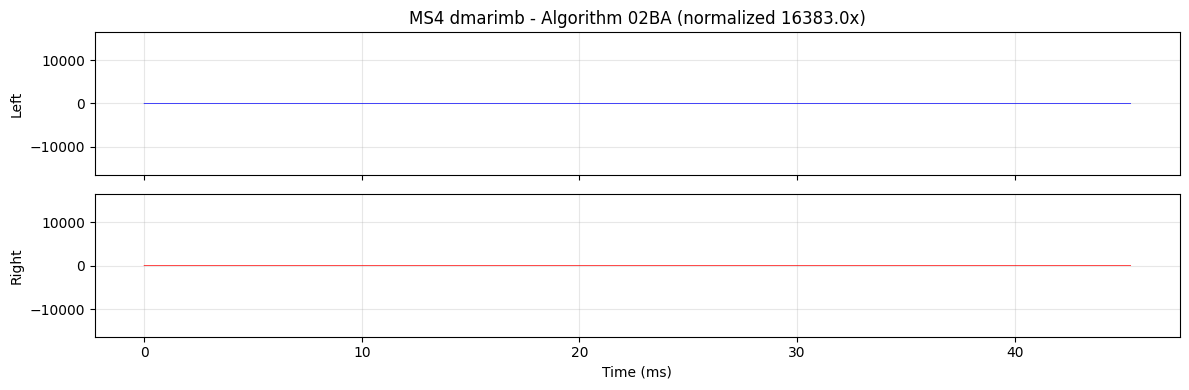

In [6]:
# Generate samples
samples = sam.run(2000, active_slots=[0])

print(f"Generated {len(samples)} samples")
print(f"L range: [{samples[:, 0].min()}, {samples[:, 0].max()}]")
print(f"R range: [{samples[:, 1].min()}, {samples[:, 1].max()}]")

plot_waveform(samples, title=f"MS4 {prog['name']} - Algorithm 02BA", normalize=True)
plt.show()

## State Inspection

In [ ]:
print_state(sam.state, slot=0)

## Instruction Trace

In [ ]:
# Reset and enable tracing
sam.reset()
sam.load_aram(aram_02ba, offset=0)
sam.load_dram(0, dram_slot0)

sam.trace_enabled = True
sam.trace_output = []

samples = sam.run(2, active_slots=[0])

print("Instruction trace (2 frames):")
for line in sam.trace_output:
    print(line)

## Notes

### Algorithm 02BA Characteristics

This algorithm is optimized for percussive/plucked sounds:

1. **No WACC in early instructions** - Unlike 027A, output accumulation happens later
2. **WACC at PC09** - First output contribution
3. **Multiple D-RAM writes to D[9], D[10]** - State update for decay/filtering
4. **D[15] written** - Control word modified during execution

### Programs Using This Algorithm

- dmarimb, dsteelg (steel guitar)
- dstrath, djguit (jazz guitar)
- dstee, dbanjo
- dstratl, dstopg2
- dzith2, dukule, dkvoi2
- dkalimb